# Deterministic Autoencoder — Gaussian Blobs on S¹

Fully-connected deterministic autoencoder that learns to map 128×128 Gaussian-blob
images (parameterised by angle θ ∈ [0, 2π)) into a 2-D latent space, with a scale
regulariser that anchors the latent curve near the unit circle.


In [1]:
import os, math, json
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
N_IMG  = 128
N_DATA = 2000
SIGMA  = 0.5
LAMBDA = 1e-6
LR     = 1e-3
BATCH  = 128
EPOCHS = 200
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
D = N_IMG * N_IMG  # 16384

# ── Timestamped run directory ─────────────────────────────────────────────────
timestamp = datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
PLOT_DIR  = os.path.join('plots', timestamp)
os.makedirs(PLOT_DIR, exist_ok=True)

config = dict(N_IMG=N_IMG, N_DATA=N_DATA, SIGMA=SIGMA, LAMBDA=LAMBDA,
              LR=LR, BATCH=BATCH, EPOCHS=EPOCHS, device=str(DEVICE))
with open(os.path.join(PLOT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Run dir : {PLOT_DIR}')
print(f'Device  : {DEVICE}')
print(json.dumps(config, indent=2))


Run dir : plots/2026-05-07-12-14-12
Device  : mps
{
  "N_IMG": 128,
  "N_DATA": 2000,
  "SIGMA": 0.5,
  "LAMBDA": 1e-06,
  "LR": 0.001,
  "BATCH": 128,
  "EPOCHS": 200,
  "device": "mps"
}


In [3]:
def gaussian_blob(theta: float, n: int = N_IMG, sigma: float = SIGMA) -> np.ndarray:
    coords = np.linspace(-2, 2, n)
    x, y = np.meshgrid(coords, coords)
    cx, cy = np.cos(theta), np.sin(theta)
    return np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma ** 2))


thetas_train = np.random.uniform(0, 2 * math.pi, N_DATA)
images = np.stack([gaussian_blob(t) for t in thetas_train], axis=0).astype(np.float32)
X = torch.from_numpy(images.reshape(N_DATA, -1))
dataset = TensorDataset(X)
loader  = DataLoader(dataset, batch_size=BATCH, shuffle=True)

print(f'Dataset : {N_DATA} images  |  {D} pixels each')


Dataset : 2000 images  |  16384 pixels each


## Curvature estimate for the dataset

PCA 32 components: 100.00% variance explained
Running iterative bandwidth selection (m=200 eval points, PCA-32 space)...


Valid estimates : 197 / 200
κ̂  median=0.0165  mean=0.0158
τ̂  median=60.5289   mean=72.3489
h* median=0.9024   mean=1.0973


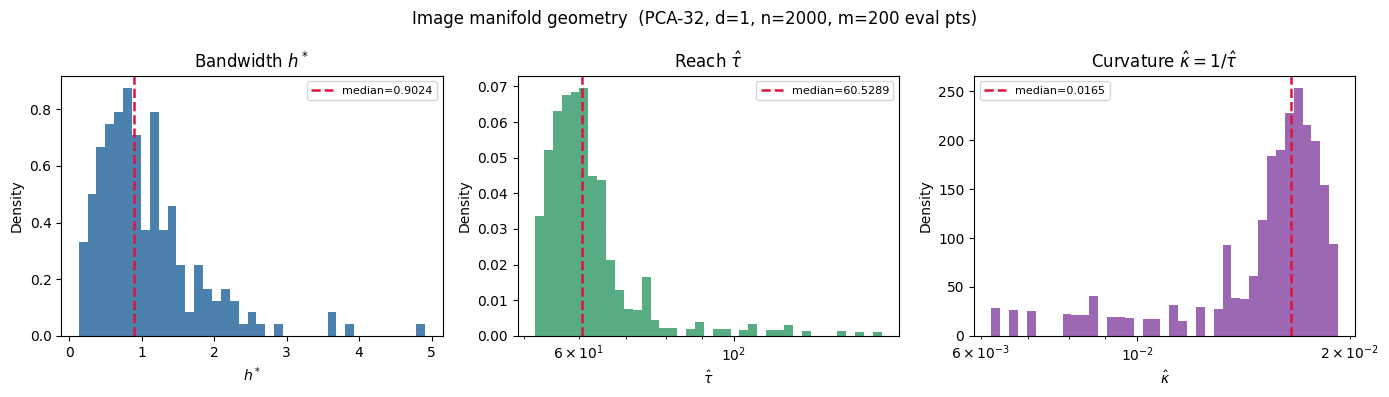

In [12]:
# Estimate the curvature of the gaussian blobs dataset: expecting constant
# Method: PCA → 32 dims for speed, then local_poly_fit + iterative_bandwidth
#         from 03-bandwidth-selection.ipynb (d=1 curve in R^N_pca).

from scipy.spatial import KDTree
from sklearn.decomposition import PCA as SklearnPCA

# ── Step 1: PCA projection ────────────────────────────────────────────────────
N_PCA = 32
pca_proj = SklearnPCA(n_components=N_PCA)
X_np  = images.reshape(N_DATA, -1)          # (2000, 16384)  numpy float32
X_pca = pca_proj.fit_transform(X_np)        # (2000, N_PCA)
var_explained = pca_proj.explained_variance_ratio_.sum()
print(f'PCA {N_PCA} components: {var_explained*100:.2f}% variance explained')

# ── Step 2: local_poly_fit (verbatim from 03-bandwidth-selection.ipynb) ───────

def local_poly_fit(x_i, neighbors, d):
    delta  = neighbors - x_i
    n_nbr  = delta.shape[0]
    n_mono = d * (d + 1) // 2
    if n_nbr < d + n_mono + 2:
        return None, None, n_nbr

    _, _, Vt = np.linalg.svd(delta, full_matrices=False)
    T = Vt[:d].T                             # (N_amb, d)  tangent frame

    v     = delta @ T                        # (n_nbr, d)  tangential coords
    Phi   = np.zeros((n_nbr, n_mono))
    col   = 0
    for i in range(d):
        for j in range(i, d):
            Phi[:, col] = v[:, i] * v[:, j]
            col += 1

    Q, _    = np.linalg.qr(T, mode='complete')
    T_perp  = Q[:, d:]                       # (N_amb, N_amb-d)  normal frame
    z_norm  = delta @ T_perp                 # (n_nbr, N_amb-d)

    A, _, _, _ = np.linalg.lstsq(Phi, z_norm, rcond=None)   # (n_mono, N_amb-d)
    N_normal   = T_perp.shape[1]

    op_norms = []
    for k in range(N_normal):
        II_k  = np.zeros((d, d))
        col   = 0
        for i in range(d):
            for j in range(i, d):
                II_k[i, j] = II_k[j, i] = A[col, k]
                col += 1
        sv = np.linalg.svd(II_k, compute_uv=False)
        op_norms.append(sv[0] if len(sv) else 0.0)

    kappa_max = max(op_norms) if op_norms else 0.0
    tau_hat   = 1.0 / kappa_max if kappa_max > 1e-10 else 10.0
    sigma_hat = np.sqrt(np.mean((z_norm - Phi @ A) ** 2))
    return tau_hat, sigma_hat, n_nbr

# ── Step 3: iterative bandwidth (adapted for eval subset) ─────────────────────

def estimate_geometry(data, d, m_eval=200, C=5.0, tol=0.02, max_iter=15):
    N_amb = data.shape[1]
    n     = len(data)
    tree  = KDTree(data)

    k0        = max(d + 5, int(np.log(n) * 2))
    eval_idx  = np.linspace(0, n - 1, m_eval, dtype=int)
    h_init    = tree.query(data[eval_idx], k=k0 + 1)[0][:, -1]

    h_out   = np.full(m_eval, np.nan)
    tau_out = np.full(m_eval, np.nan)
    sig_out = np.full(m_eval, np.nan)

    for ii, i in enumerate(eval_idx):
        h_i = h_init[ii]
        tau_i, sig_i = np.nan, np.nan
        for _ in range(max_iter):
            nbrs = data[tree.query_ball_point(data[i], h_i)]
            tau_i, sig_i, _ = local_poly_fit(data[i], nbrs, d)
            if tau_i is None:
                h_i *= 1.2
                continue
            h_new = np.sqrt(C * np.sqrt(N_amb) * sig_i * tau_i)
            if h_new < 1e-8:
                break
            converged = abs(h_new - h_i) / (h_i + 1e-12) < tol
            h_i = h_new
            if converged:
                break
        h_out[ii], tau_out[ii], sig_out[ii] = h_i, tau_i if tau_i else np.nan, sig_i if sig_i else np.nan

    return h_out, tau_out, sig_out

print('Running iterative bandwidth selection (m=200 eval points, PCA-32 space)...')
h_star, tau_hat, sig_hat = estimate_geometry(X_pca, d=1, m_eval=200)
kappa_hat = np.where((tau_hat > 0) & np.isfinite(tau_hat), 1.0 / tau_hat, np.nan)

valid = np.isfinite(kappa_hat)
print(f'Valid estimates : {valid.sum()} / {len(kappa_hat)}')
print(f'κ̂  median={np.nanmedian(kappa_hat):.4f}  mean={np.nanmean(kappa_hat):.4f}')
print(f'τ̂  median={np.nanmedian(tau_hat):.4f}   mean={np.nanmean(tau_hat):.4f}')
print(f'h* median={np.nanmedian(h_star):.4f}   mean={np.nanmean(h_star):.4f}')

# ── Step 4: Histograms ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Image manifold geometry  (PCA-{N_PCA}, d=1, n={N_DATA}, m=200 eval pts)',
             fontsize=12)

def _hist(ax, vals, title, xlabel, color, vline=None, vline_label=None, log_x=False):
    v = vals[np.isfinite(vals)]
    if len(v) == 0:
        ax.set_title(title + ' (no data)'); return
    lo, hi = np.percentile(v, [1, 99])
    bins = (np.logspace(np.log10(max(lo, 1e-6)), np.log10(hi), 40)
            if log_x else np.linspace(lo, hi, 40))
    ax.hist(v, bins=bins, color=color, edgecolor='none', alpha=0.85, density=True)
    ax.axvline(np.median(v), color='crimson', lw=1.8, ls='--',
               label=f'median={np.median(v):.4f}')
    if vline is not None:
        ax.axvline(vline, color='black', lw=1.5, ls=':', label=vline_label or '')
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel); ax.set_ylabel('Density'); ax.set_title(title)
    ax.legend(fontsize=8)

_hist(axes[0], h_star,    'Bandwidth $h^*$',     '$h^*$',           '#2d6a9f')
_hist(axes[1], tau_hat,   'Reach $\\hat{\\tau}$', '$\\hat{\\tau}$',  '#3a9e6e', log_x=True)
_hist(axes[2], kappa_hat, 'Curvature $\\hat{\\kappa} = 1/\\hat{\\tau}$',
      '$\\hat{\\kappa}$', '#8b4ea6', log_x=True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'image_manifold_geometry.png'), dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig)


## Autoencoder

In [4]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D, 512),   nn.GELU(),
            nn.Linear(512, 128), nn.GELU(),
            nn.Linear(128, 32),  nn.GELU(),
            nn.Linear(32, 2),
        )
    def forward(self, x): return self.net(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),    nn.GELU(),
            nn.Linear(32, 128),  nn.GELU(),
            nn.Linear(128, 512), nn.GELU(),
            nn.Linear(512, D),   nn.Sigmoid(),
        )
    def forward(self, z): return self.net(z)


encoder = Encoder().to(DEVICE)
decoder = Decoder().to(DEVICE)
optim   = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()), lr=LR
)
print(encoder)
print(decoder)


Encoder(
  (net): Sequential(
    (0): Linear(in_features=16384, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=32, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)
Decoder(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=512, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=512, out_features=16384, bias=True)
    (7): Sigmoid()
  )
)


In [5]:
def _encode_thetas(thetas: np.ndarray) -> np.ndarray:
    imgs = torch.from_numpy(
        np.stack([gaussian_blob(t) for t in thetas], 0).astype(np.float32)
    ).reshape(len(thetas), -1).to(DEVICE)
    encoder.eval()
    with torch.no_grad():
        zs = encoder(imgs).cpu().numpy()
    encoder.train()
    return zs


def _draw_latent_curve(ax, epoch: int, n_samples: int = 100):
    thetas_v = np.linspace(0, 2 * math.pi, n_samples, endpoint=False)
    zs = _encode_thetas(thetas_v)

    pts      = np.vstack([zs, zs[:1]])
    t_closed = np.append(thetas_v, thetas_v[0])
    segments = [pts[i:i + 2] for i in range(len(pts) - 1)]
    colors   = plt.cm.hsv(t_closed[:-1] / (2 * math.pi))

    lc = LineCollection(segments, colors=colors, linewidth=1.5, zorder=2)
    ax.add_collection(lc)
    ax.scatter(zs[:, 0], zs[:, 1],
               c=thetas_v / (2 * math.pi), cmap='hsv',
               s=18, zorder=3, linewidths=0)

    t_circ = np.linspace(0, 2 * math.pi, 300)
    ax.plot(np.cos(t_circ), np.sin(t_circ), '--', color='#888888',
            linewidth=1, zorder=1, label='unit circle')

    zlim = max(float(np.abs(zs).max()), 1.1) + 0.3
    ax.set_xlim(-zlim, zlim); ax.set_ylim(-zlim, zlim)
    ax.set_aspect('equal')
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
    ax.set_title(f'Latent curve (epoch {epoch})')
    ax.legend(fontsize=8)


def visualise(epoch: int):
    encoder.eval(); decoder.eval()

    gt   = gaussian_blob(math.pi / 4)
    x_in = torch.from_numpy(gt.astype(np.float32).ravel()).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        z_ex  = encoder(x_in)
        x_rec = decoder(z_ex).cpu().numpy().reshape(N_IMG, N_IMG)

    fig = plt.figure(figsize=(14, 5))
    gs_outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
    gs_left  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=0.05)

    ax_gt  = fig.add_subplot(gs_left[0])
    ax_rec = fig.add_subplot(gs_left[1])
    ax_lat = fig.add_subplot(gs_outer[1])

    imkw = dict(origin='lower', extent=[-2, 2, -2, 2], cmap='gray', vmin=0, vmax=1)
    ax_gt.imshow(gt,     **imkw); ax_gt.set_title('Ground truth',   fontsize=10); ax_gt.axis('off')
    ax_rec.imshow(x_rec, **imkw); ax_rec.set_title('Reconstructed', fontsize=10); ax_rec.axis('off')

    _draw_latent_curve(ax_lat, epoch, n_samples=100)

    fig.savefig(os.path.join(PLOT_DIR, f'epoch_{epoch:03d}.png'), dpi=100, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    encoder.train(); decoder.train()


epoch   1  rec=0.09940  reg=823.29631  total=0.10023
epoch   2  rec=0.04454  reg=675.46381  total=0.04522
epoch   3  rec=0.03648  reg=1093.99193  total=0.03757
epoch   4  rec=0.03064  reg=562.94290  total=0.03120
epoch   5  rec=0.02244  reg=468.67135  total=0.02291
epoch   6  rec=0.01758  reg=402.18793  total=0.01798
epoch   7  rec=0.01528  reg=341.31879  total=0.01562
epoch   8  rec=0.01412  reg=312.44574  total=0.01443
epoch   9  rec=0.01350  reg=269.00540  total=0.01377
epoch  10  rec=0.01297  reg=226.54692  total=0.01320


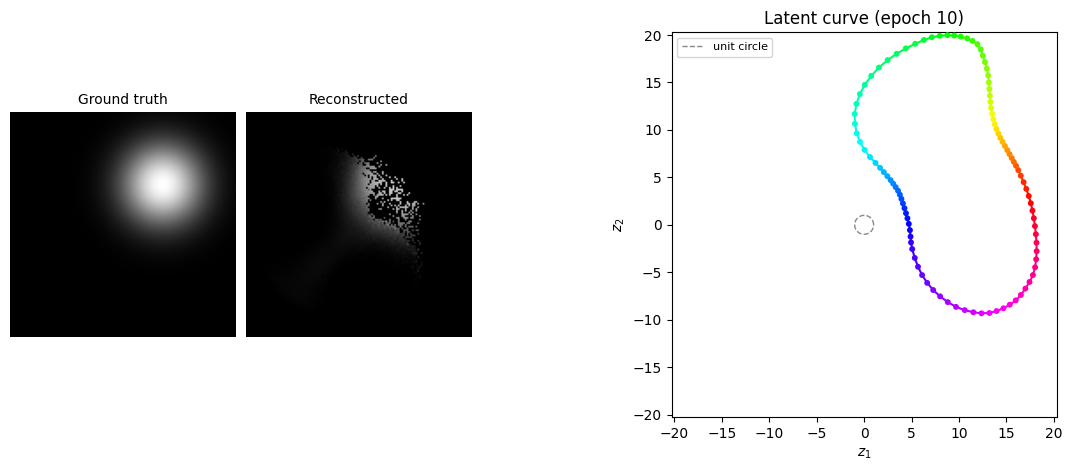

epoch  11  rec=0.01281  reg=197.23533  total=0.01301
epoch  12  rec=0.01250  reg=173.66567  total=0.01268
epoch  13  rec=0.01255  reg=173.20487  total=0.01273
epoch  14  rec=0.01205  reg=163.04468  total=0.01221
epoch  15  rec=0.01173  reg=143.90101  total=0.01187
epoch  16  rec=0.01158  reg=131.45457  total=0.01171
epoch  17  rec=0.01125  reg=121.20869  total=0.01137
epoch  18  rec=0.01105  reg=111.19073  total=0.01116
epoch  19  rec=0.01087  reg=104.29227  total=0.01098
epoch  20  rec=0.01069  reg=100.34566  total=0.01079


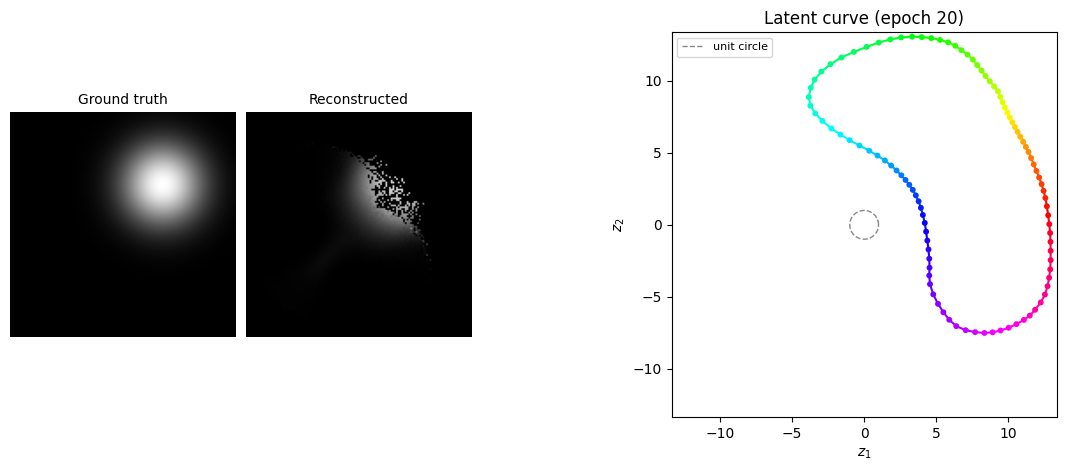

epoch  21  rec=0.01043  reg=94.85019  total=0.01052
epoch  22  rec=0.01033  reg=89.58207  total=0.01042
epoch  23  rec=0.01009  reg=93.64141  total=0.01019
epoch  24  rec=0.00988  reg=91.07074  total=0.00997
epoch  25  rec=0.00962  reg=84.23827  total=0.00970
epoch  26  rec=0.00940  reg=80.11460  total=0.00948
epoch  27  rec=0.00936  reg=78.99137  total=0.00944
epoch  28  rec=0.00918  reg=78.66373  total=0.00926
epoch  29  rec=0.00898  reg=77.78848  total=0.00906
epoch  30  rec=0.00878  reg=78.41527  total=0.00886


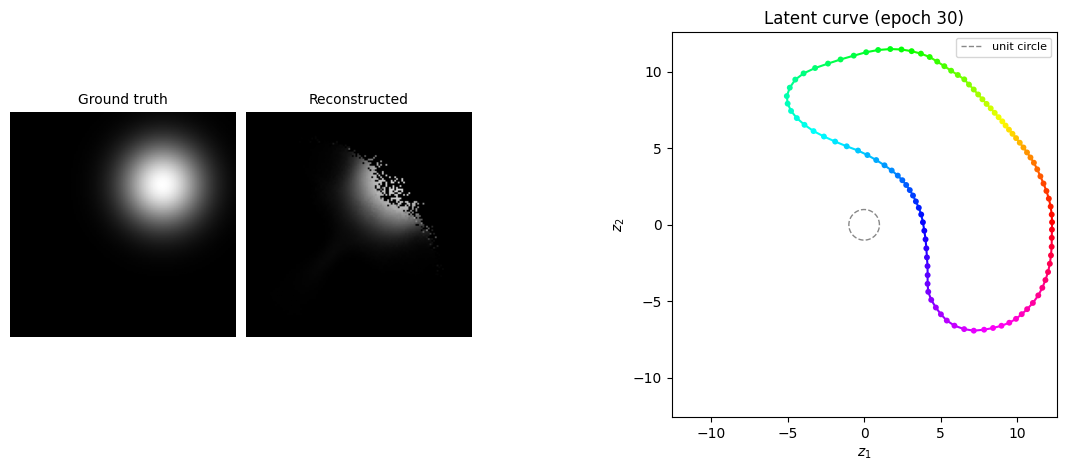

epoch  31  rec=0.00861  reg=75.47328  total=0.00869
epoch  32  rec=0.00846  reg=71.64405  total=0.00853
epoch  33  rec=0.00825  reg=68.23900  total=0.00832
epoch  34  rec=0.00808  reg=65.39687  total=0.00815
epoch  35  rec=0.00800  reg=66.72985  total=0.00806
epoch  36  rec=0.00787  reg=68.23530  total=0.00794
epoch  37  rec=0.00760  reg=66.44242  total=0.00766
epoch  38  rec=0.00745  reg=63.05797  total=0.00751
epoch  39  rec=0.00725  reg=60.47551  total=0.00731
epoch  40  rec=0.00730  reg=63.70100  total=0.00737


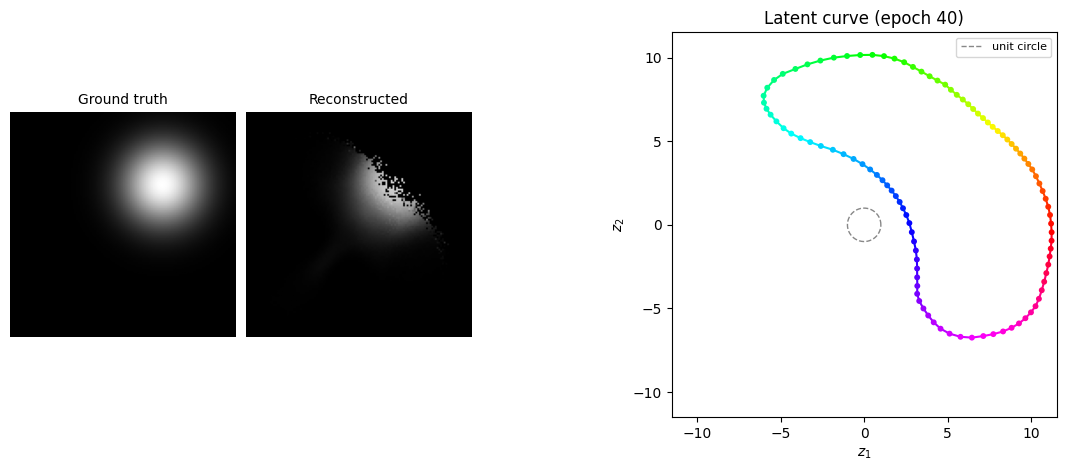

epoch  41  rec=0.00716  reg=69.99050  total=0.00723
epoch  42  rec=0.00707  reg=72.23187  total=0.00714
epoch  43  rec=0.00686  reg=70.82811  total=0.00693
epoch  44  rec=0.00670  reg=67.52153  total=0.00677
epoch  45  rec=0.00666  reg=64.13322  total=0.00673
epoch  46  rec=0.00654  reg=60.83521  total=0.00660
epoch  47  rec=0.00641  reg=57.86473  total=0.00647
epoch  48  rec=0.00633  reg=55.46767  total=0.00638
epoch  49  rec=0.00619  reg=53.25271  total=0.00624
epoch  50  rec=0.00603  reg=51.24495  total=0.00608


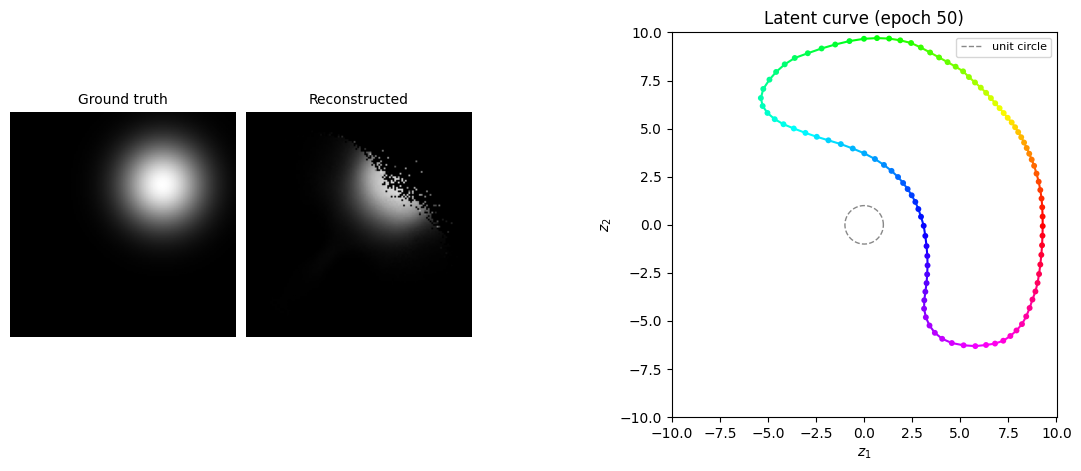

epoch  51  rec=0.00593  reg=50.47503  total=0.00598
epoch  52  rec=0.00577  reg=51.72829  total=0.00582
epoch  53  rec=0.00557  reg=51.66173  total=0.00562
epoch  54  rec=0.00538  reg=51.62698  total=0.00543
epoch  55  rec=0.00524  reg=50.33564  total=0.00529
epoch  56  rec=0.00511  reg=48.43356  total=0.00515
epoch  57  rec=0.00496  reg=46.49589  total=0.00501
epoch  58  rec=0.00483  reg=45.36507  total=0.00487
epoch  59  rec=0.00481  reg=46.77527  total=0.00486
epoch  60  rec=0.00464  reg=49.34059  total=0.00469


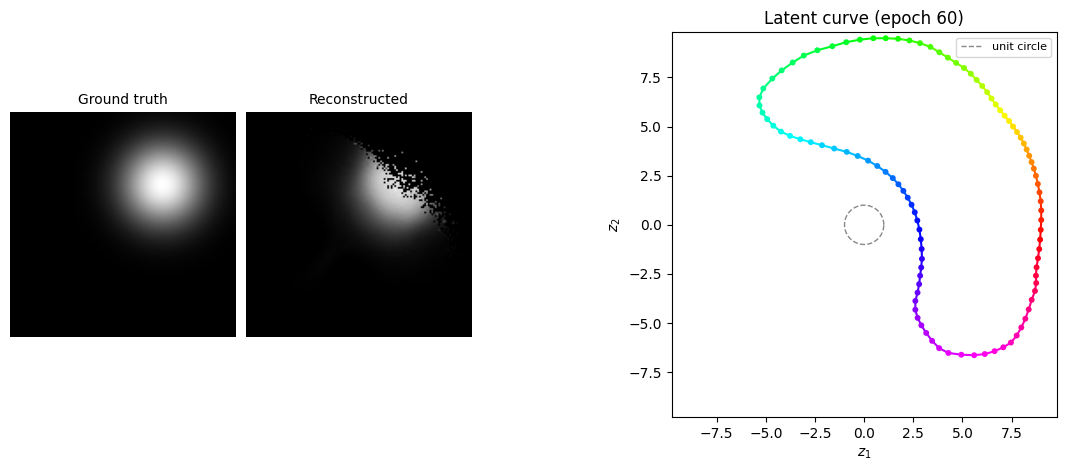

epoch  61  rec=0.00442  reg=48.14091  total=0.00447
epoch  62  rec=0.00425  reg=46.30878  total=0.00429
epoch  63  rec=0.00412  reg=44.52173  total=0.00417
epoch  64  rec=0.00397  reg=42.68495  total=0.00401
epoch  65  rec=0.00390  reg=42.50636  total=0.00394
epoch  66  rec=0.00370  reg=44.13731  total=0.00375
epoch  67  rec=0.00350  reg=42.36305  total=0.00354
epoch  68  rec=0.00333  reg=41.00628  total=0.00337
epoch  69  rec=0.00317  reg=39.47011  total=0.00321
epoch  70  rec=0.00305  reg=38.62132  total=0.00309


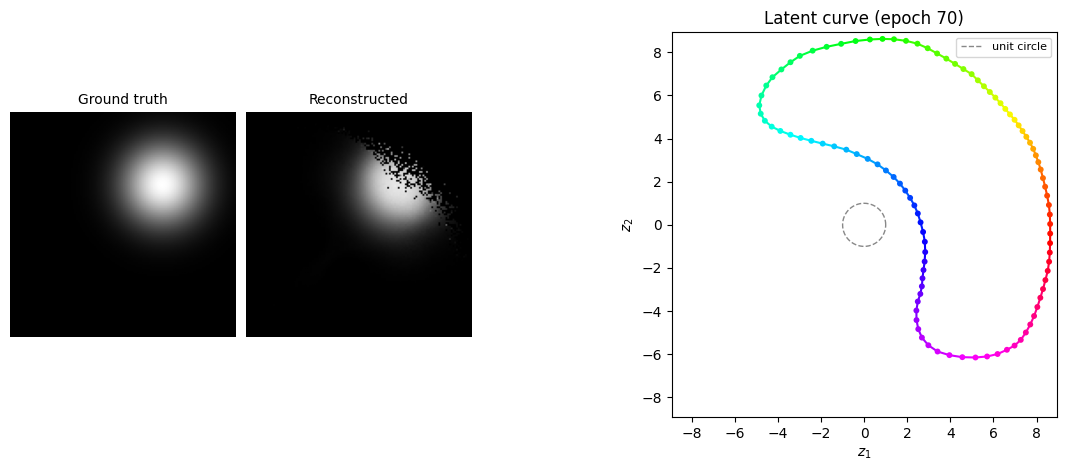

epoch  71  rec=0.00292  reg=39.23441  total=0.00296
epoch  72  rec=0.00272  reg=38.12260  total=0.00276
epoch  73  rec=0.00246  reg=37.16008  total=0.00250
epoch  74  rec=0.00229  reg=36.57886  total=0.00233
epoch  75  rec=0.00213  reg=37.83530  total=0.00217
epoch  76  rec=0.00193  reg=37.50525  total=0.00197
epoch  77  rec=0.00187  reg=39.30244  total=0.00190
epoch  78  rec=0.00162  reg=39.46696  total=0.00166
epoch  79  rec=0.00148  reg=38.57018  total=0.00151
epoch  80  rec=0.00135  reg=36.94219  total=0.00139


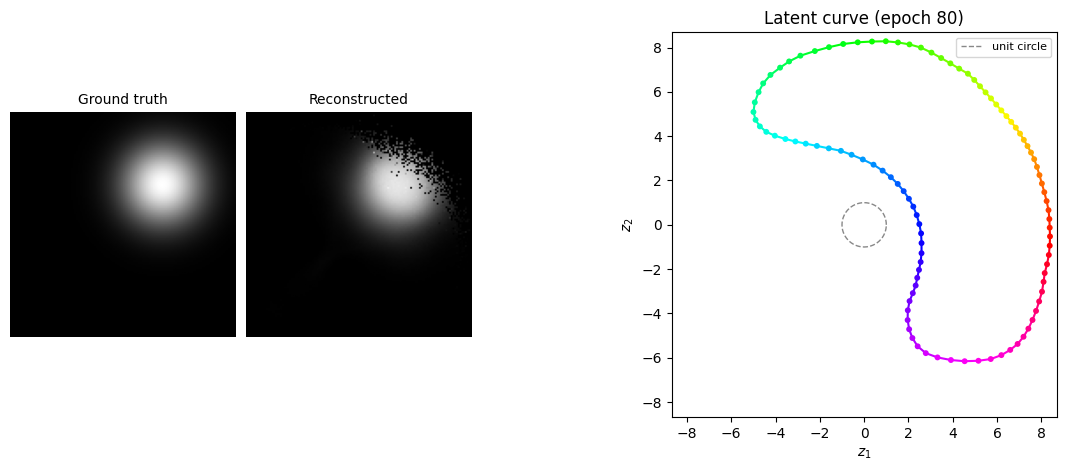

epoch  81  rec=0.00123  reg=35.42468  total=0.00126
epoch  82  rec=0.00113  reg=34.40753  total=0.00117
epoch  83  rec=0.00104  reg=33.94932  total=0.00108
epoch  84  rec=0.00099  reg=34.99654  total=0.00103
epoch  85  rec=0.00087  reg=34.90871  total=0.00090
epoch  86  rec=0.00075  reg=34.86113  total=0.00079
epoch  87  rec=0.00067  reg=34.08032  total=0.00070
epoch  88  rec=0.00059  reg=33.45655  total=0.00062
epoch  89  rec=0.00054  reg=33.23480  total=0.00057
epoch  90  rec=0.00048  reg=32.65352  total=0.00052


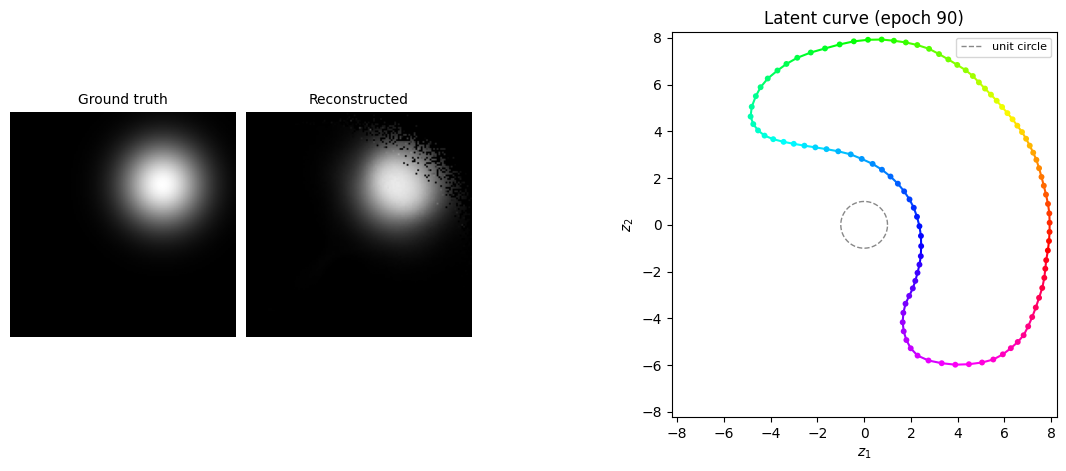

epoch  91  rec=0.00046  reg=32.20145  total=0.00049
epoch  92  rec=0.00043  reg=33.07966  total=0.00046
epoch  93  rec=0.00033  reg=32.66173  total=0.00036
epoch  94  rec=0.00029  reg=32.09917  total=0.00032
epoch  95  rec=0.00026  reg=31.06250  total=0.00029
epoch  96  rec=0.00023  reg=30.44162  total=0.00026
epoch  97  rec=0.00021  reg=29.70564  total=0.00024
epoch  98  rec=0.00020  reg=29.14399  total=0.00023
epoch  99  rec=0.00020  reg=28.66129  total=0.00023
epoch 100  rec=0.00018  reg=28.68122  total=0.00021


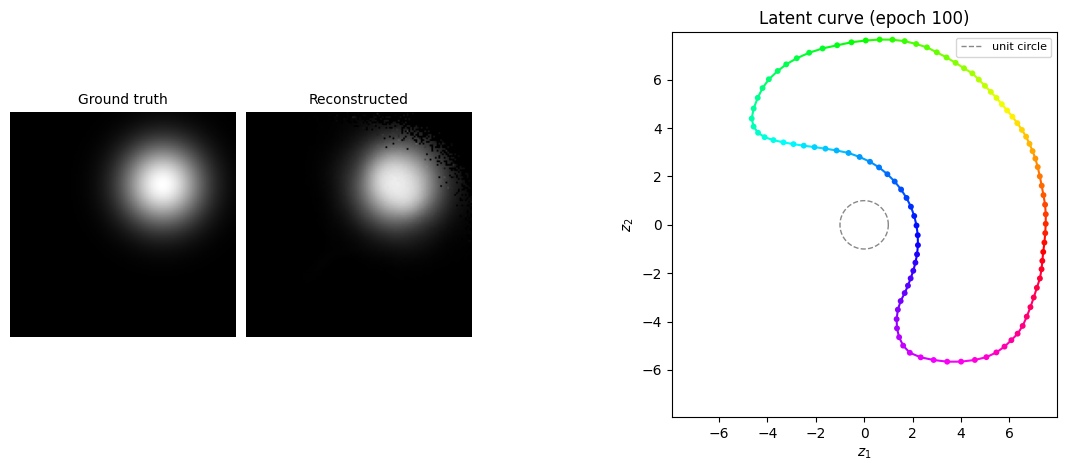

epoch 101  rec=0.00017  reg=28.49631  total=0.00020
epoch 102  rec=0.00020  reg=28.91436  total=0.00023
epoch 103  rec=0.00016  reg=28.91430  total=0.00019
epoch 104  rec=0.00013  reg=28.97331  total=0.00016
epoch 105  rec=0.00013  reg=28.37874  total=0.00016
epoch 106  rec=0.00011  reg=27.97208  total=0.00014
epoch 107  rec=0.00011  reg=27.38430  total=0.00014
epoch 108  rec=0.00010  reg=26.95303  total=0.00013
epoch 109  rec=0.00009  reg=26.47498  total=0.00012
epoch 110  rec=0.00010  reg=26.05096  total=0.00013


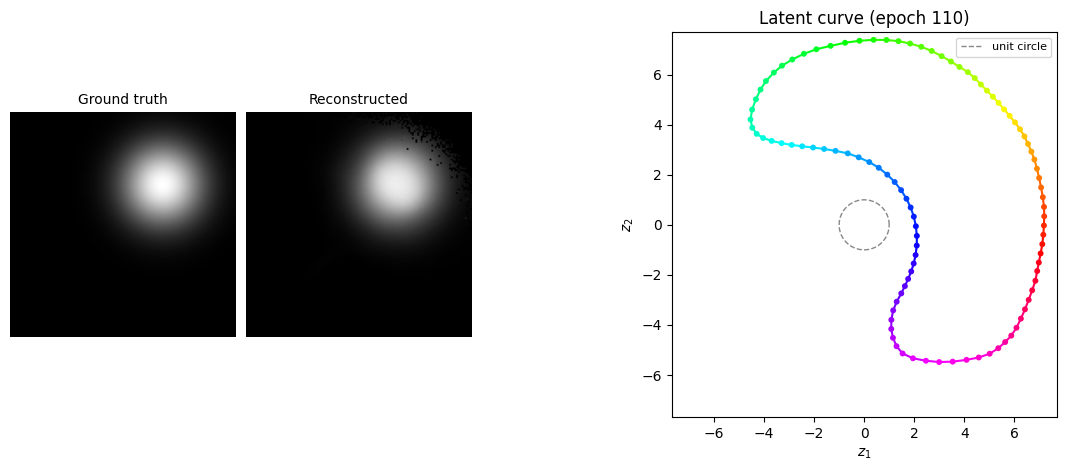

epoch 111  rec=0.00010  reg=25.80446  total=0.00013
epoch 112  rec=0.00013  reg=26.50952  total=0.00016
epoch 113  rec=0.00008  reg=26.45142  total=0.00011
epoch 114  rec=0.00009  reg=26.15292  total=0.00012
epoch 115  rec=0.00010  reg=25.94405  total=0.00012
epoch 116  rec=0.00010  reg=25.98147  total=0.00013
epoch 117  rec=0.00007  reg=25.70437  total=0.00010
epoch 118  rec=0.00007  reg=25.29333  total=0.00009
epoch 119  rec=0.00009  reg=24.95238  total=0.00012
epoch 120  rec=0.00007  reg=24.92055  total=0.00010


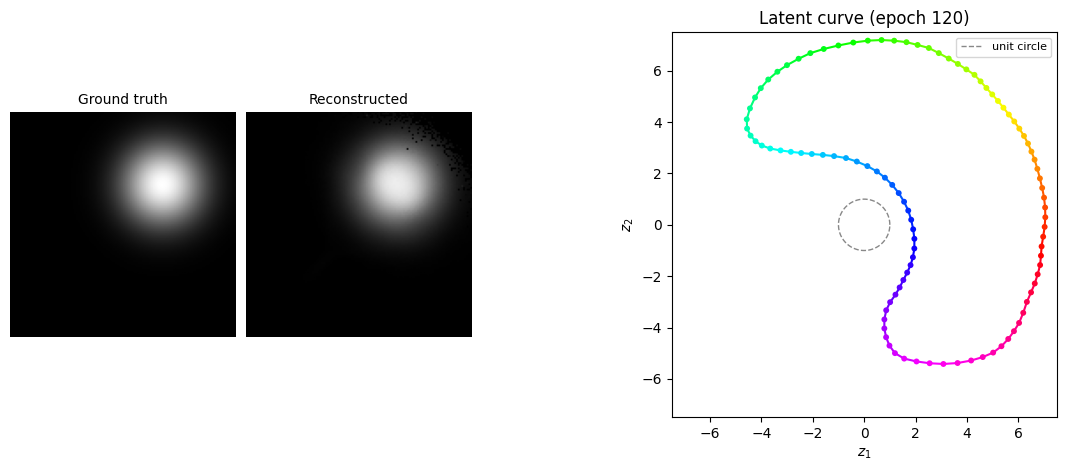

epoch 121  rec=0.00007  reg=24.46169  total=0.00009
epoch 122  rec=0.00008  reg=24.44464  total=0.00010
epoch 123  rec=0.00006  reg=24.04901  total=0.00008
epoch 124  rec=0.00006  reg=23.71338  total=0.00008
epoch 125  rec=0.00008  reg=23.59615  total=0.00010
epoch 126  rec=0.00009  reg=23.57274  total=0.00012
epoch 127  rec=0.00008  reg=23.68324  total=0.00010
epoch 128  rec=0.00006  reg=23.63586  total=0.00008
epoch 129  rec=0.00005  reg=23.22602  total=0.00007
epoch 130  rec=0.00004  reg=22.69687  total=0.00006


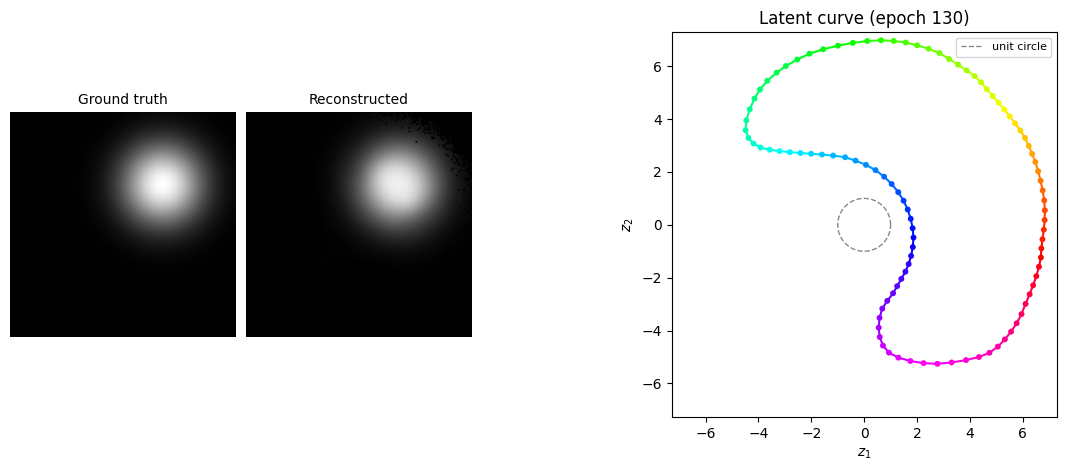

epoch 131  rec=0.00004  reg=22.10123  total=0.00006
epoch 132  rec=0.00004  reg=21.49262  total=0.00006
epoch 133  rec=0.00004  reg=21.11636  total=0.00006
epoch 134  rec=0.00004  reg=20.73640  total=0.00006
epoch 135  rec=0.00004  reg=20.34950  total=0.00006
epoch 136  rec=0.00003  reg=20.01963  total=0.00005
epoch 137  rec=0.00005  reg=19.87462  total=0.00007
epoch 138  rec=0.00006  reg=20.09612  total=0.00008
epoch 139  rec=0.00009  reg=20.53081  total=0.00011
epoch 140  rec=0.00009  reg=21.27756  total=0.00012


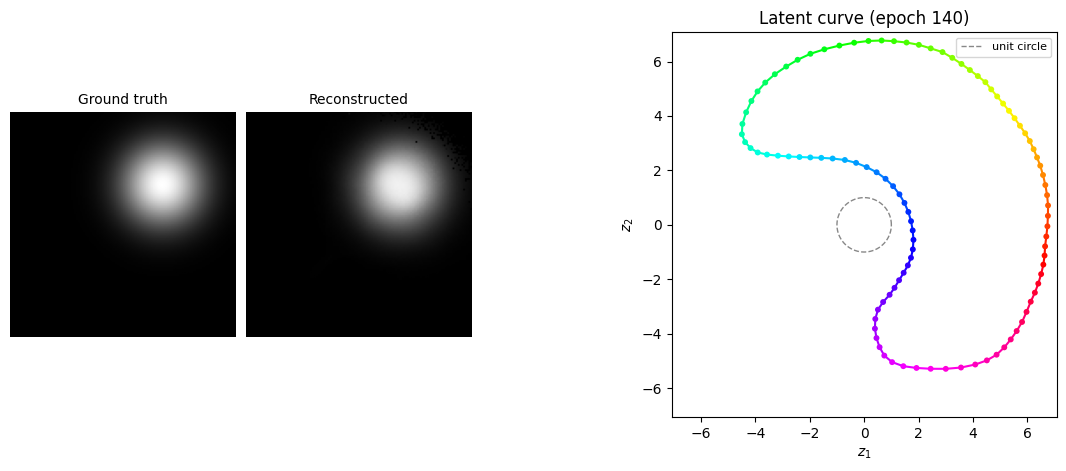

epoch 141  rec=0.00006  reg=21.13496  total=0.00008
epoch 142  rec=0.00004  reg=21.01822  total=0.00006
epoch 143  rec=0.00003  reg=20.54790  total=0.00005
epoch 144  rec=0.00003  reg=20.03881  total=0.00005
epoch 145  rec=0.00003  reg=19.59236  total=0.00005
epoch 146  rec=0.00002  reg=19.17566  total=0.00004
epoch 147  rec=0.00002  reg=18.71108  total=0.00004
epoch 148  rec=0.00002  reg=18.29231  total=0.00004
epoch 149  rec=0.00005  reg=18.18197  total=0.00007
epoch 150  rec=0.00018  reg=19.92300  total=0.00020


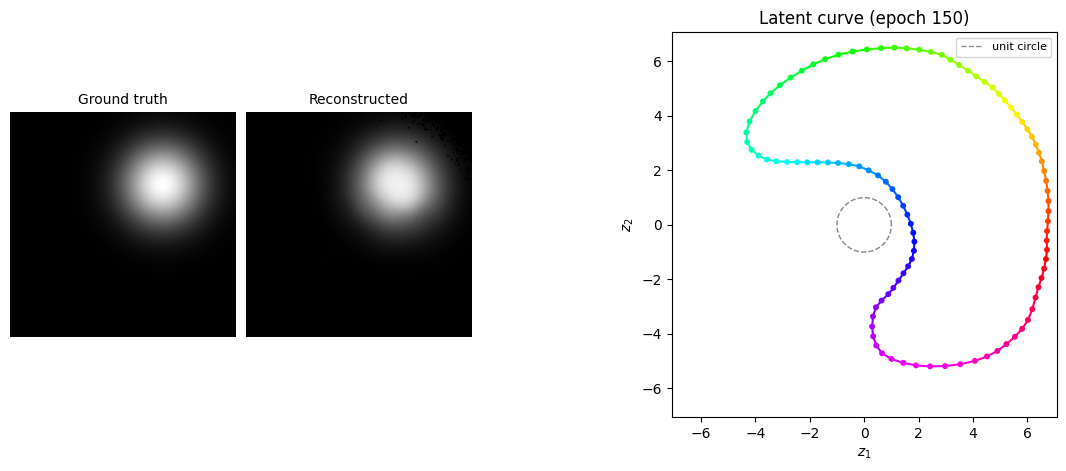

epoch 151  rec=0.00021  reg=21.56939  total=0.00023
epoch 152  rec=0.00011  reg=22.12930  total=0.00013
epoch 153  rec=0.00013  reg=22.50482  total=0.00015
epoch 154  rec=0.00006  reg=22.55822  total=0.00009
epoch 155  rec=0.00005  reg=22.04657  total=0.00007
epoch 156  rec=0.00004  reg=21.66024  total=0.00006
epoch 157  rec=0.00002  reg=21.03031  total=0.00004
epoch 158  rec=0.00002  reg=20.46728  total=0.00004
epoch 159  rec=0.00002  reg=19.89956  total=0.00004
epoch 160  rec=0.00002  reg=19.40499  total=0.00004


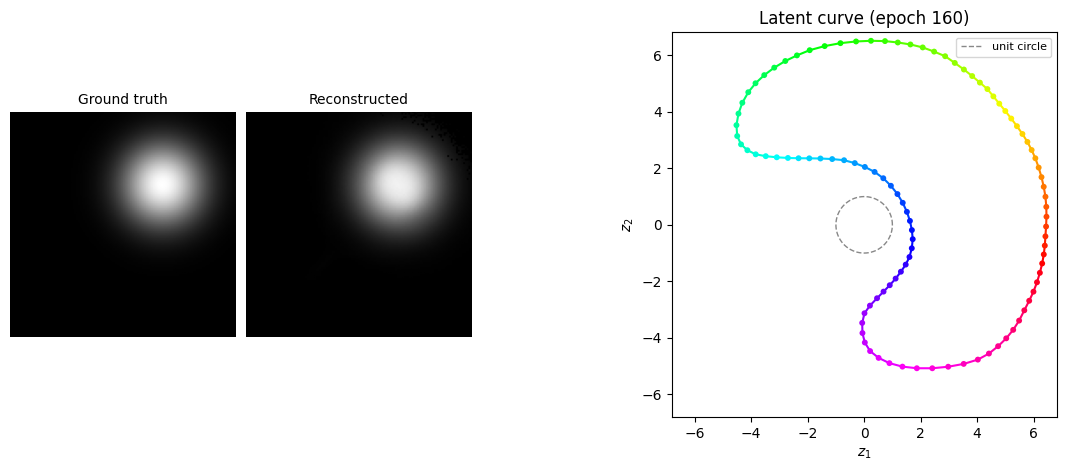

epoch 161  rec=0.00002  reg=18.86016  total=0.00004
epoch 162  rec=0.00002  reg=18.35911  total=0.00004
epoch 163  rec=0.00002  reg=17.96444  total=0.00004
epoch 164  rec=0.00002  reg=17.64507  total=0.00003
epoch 165  rec=0.00002  reg=17.30782  total=0.00003
epoch 166  rec=0.00002  reg=16.95522  total=0.00003
epoch 167  rec=0.00002  reg=16.64238  total=0.00003
epoch 168  rec=0.00002  reg=16.33130  total=0.00003
epoch 169  rec=0.00002  reg=16.02264  total=0.00003
epoch 170  rec=0.00002  reg=15.77309  total=0.00003


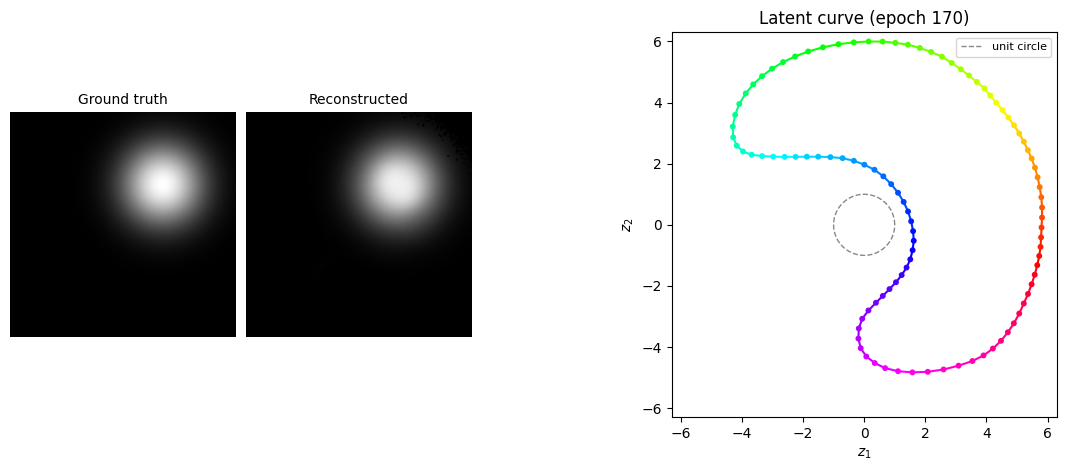

epoch 171  rec=0.00002  reg=15.44242  total=0.00003
epoch 172  rec=0.00002  reg=15.17613  total=0.00003
epoch 173  rec=0.00002  reg=14.96518  total=0.00003
epoch 174  rec=0.00003  reg=14.89838  total=0.00004
epoch 175  rec=0.00005  reg=15.10198  total=0.00006
epoch 176  rec=0.00003  reg=15.21192  total=0.00004
epoch 177  rec=0.00002  reg=15.11367  total=0.00004
epoch 178  rec=0.00002  reg=14.93089  total=0.00004
epoch 179  rec=0.00002  reg=14.71357  total=0.00003
epoch 180  rec=0.00002  reg=14.52920  total=0.00004


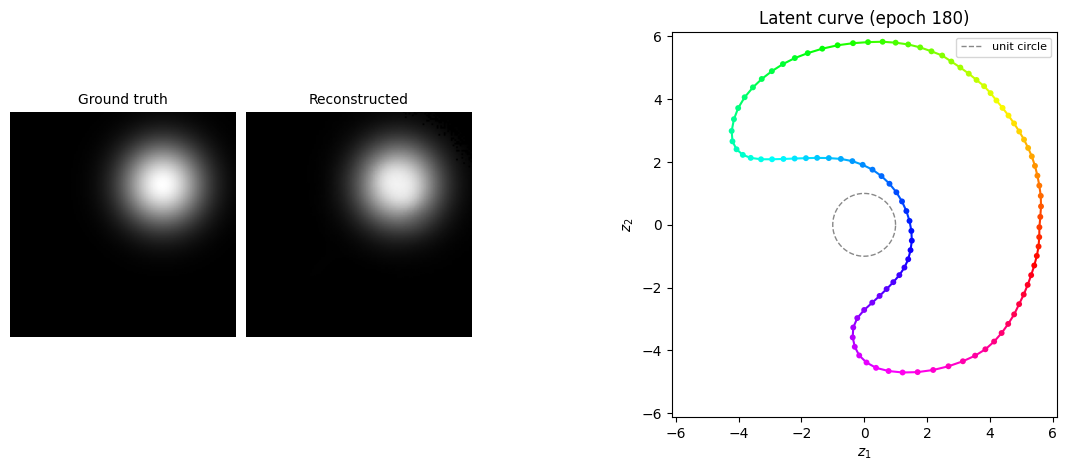

epoch 181  rec=0.00002  reg=14.33928  total=0.00003
epoch 182  rec=0.00002  reg=14.31344  total=0.00004
epoch 183  rec=0.00002  reg=14.18750  total=0.00004
epoch 184  rec=0.00002  reg=13.96568  total=0.00003
epoch 185  rec=0.00002  reg=13.81538  total=0.00003
epoch 186  rec=0.00003  reg=13.69986  total=0.00004
epoch 187  rec=0.00003  reg=13.69038  total=0.00004
epoch 188  rec=0.00002  reg=13.62928  total=0.00003
epoch 189  rec=0.00002  reg=13.48299  total=0.00004
epoch 190  rec=0.00003  reg=13.38514  total=0.00004


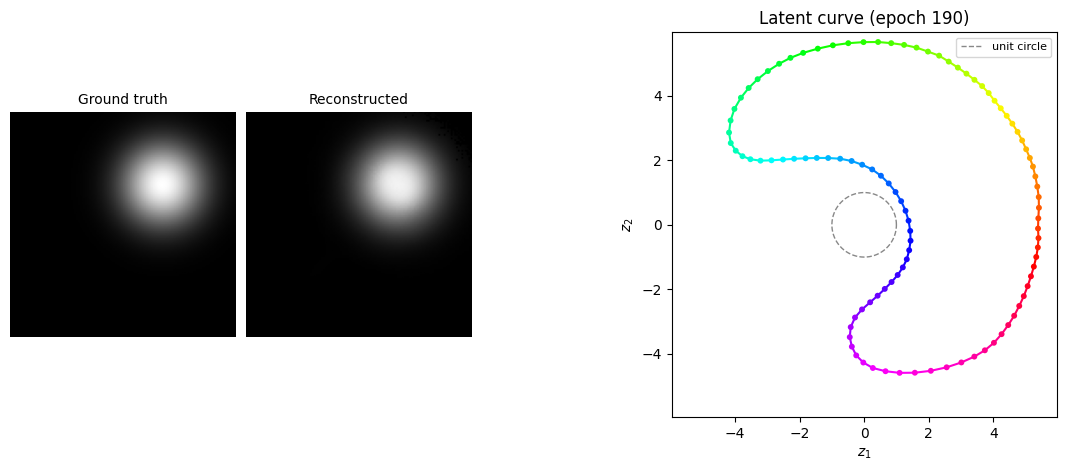

epoch 191  rec=0.00002  reg=13.37394  total=0.00004
epoch 192  rec=0.00002  reg=13.33602  total=0.00004
epoch 193  rec=0.00002  reg=13.27415  total=0.00003
epoch 194  rec=0.00002  reg=13.14649  total=0.00003
epoch 195  rec=0.00002  reg=12.98970  total=0.00003
epoch 196  rec=0.00005  reg=13.05172  total=0.00006
epoch 197  rec=0.00007  reg=13.24282  total=0.00008
epoch 198  rec=0.00019  reg=14.33334  total=0.00020
epoch 199  rec=0.00012  reg=15.43595  total=0.00013
epoch 200  rec=0.00007  reg=15.79392  total=0.00008


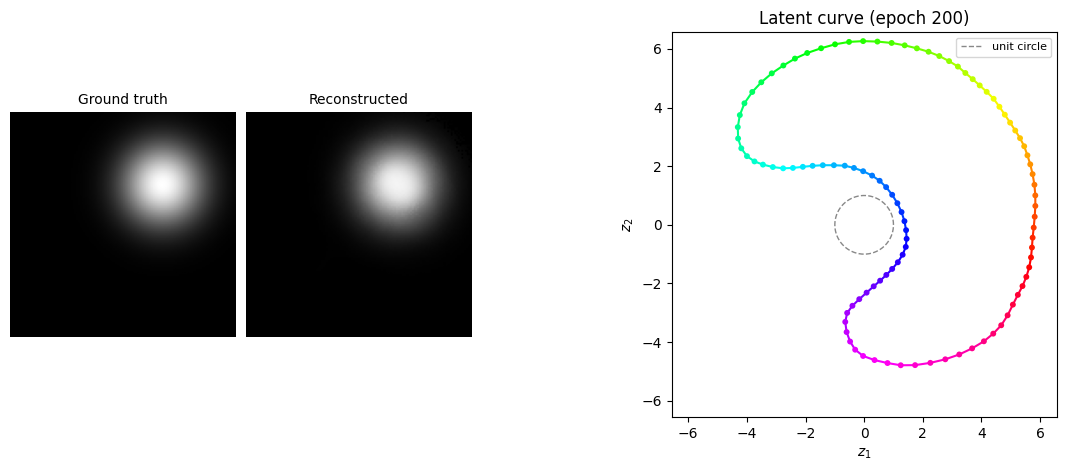

In [6]:
encoder.train(); decoder.train()

for epoch in range(1, EPOCHS + 1):
    rec_sum = reg_sum = 0.0

    for (xb,) in loader:
        xb = xb.to(DEVICE)
        z  = encoder(xb)
        xh = decoder(z)

        loss_rec = ((xb - xh) ** 2).mean()
        loss_reg = ((z.norm(dim=1) - 1) ** 2).mean()
        loss     = loss_rec + LAMBDA * loss_reg

        optim.zero_grad()
        loss.backward()
        optim.step()

        rec_sum += loss_rec.item()
        reg_sum += loss_reg.item()

    nb_     = len(loader)
    rec_avg = rec_sum / nb_
    reg_avg = reg_sum / nb_
    tot_avg = rec_avg + LAMBDA * reg_avg

    print(f'epoch {epoch:3d}  rec={rec_avg:.5f}  reg={reg_avg:.5f}  total={tot_avg:.5f}')

    if epoch % 10 == 0:
        visualise(epoch)


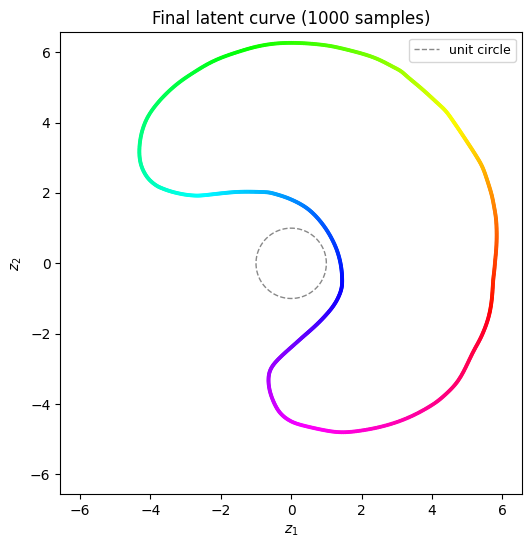

Done. Saved to plots/2026-05-07-12-14-12/final_latent_curve.png


In [7]:
encoder.eval()

n_final      = 1000
thetas_final = np.linspace(0, 2 * math.pi, n_final, endpoint=False)
zs_final     = _encode_thetas(thetas_final)

fig, ax = plt.subplots(figsize=(6, 6))

pts      = np.vstack([zs_final, zs_final[:1]])
t_closed = np.append(thetas_final, thetas_final[0])
segments = [pts[i:i + 2] for i in range(len(pts) - 1)]
colors   = plt.cm.hsv(t_closed[:-1] / (2 * math.pi))

lc = LineCollection(segments, colors=colors, linewidth=2, zorder=2)
ax.add_collection(lc)
ax.scatter(zs_final[:, 0], zs_final[:, 1],
           c=thetas_final / (2 * math.pi), cmap='hsv',
           s=8, zorder=3, linewidths=0)

t_circ = np.linspace(0, 2 * math.pi, 300)
ax.plot(np.cos(t_circ), np.sin(t_circ), '--', color='#888888', linewidth=1, label='unit circle')

zlim = max(float(np.abs(zs_final).max()), 1.1) + 0.3
ax.set_xlim(-zlim, zlim); ax.set_ylim(-zlim, zlim)
ax.set_aspect('equal')
ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
ax.set_title('Final latent curve (1000 samples)')
ax.legend(fontsize=9)

out_path = os.path.join(PLOT_DIR, 'final_latent_curve.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Done. Saved to {out_path}')


Adaptive bandwidth h = 0.3515  (median 20-NN distance)
Estimated 1000 / 1000 points successfully
κ  mean=0.3250  median=0.2512  min=0.0004  max=1.4764


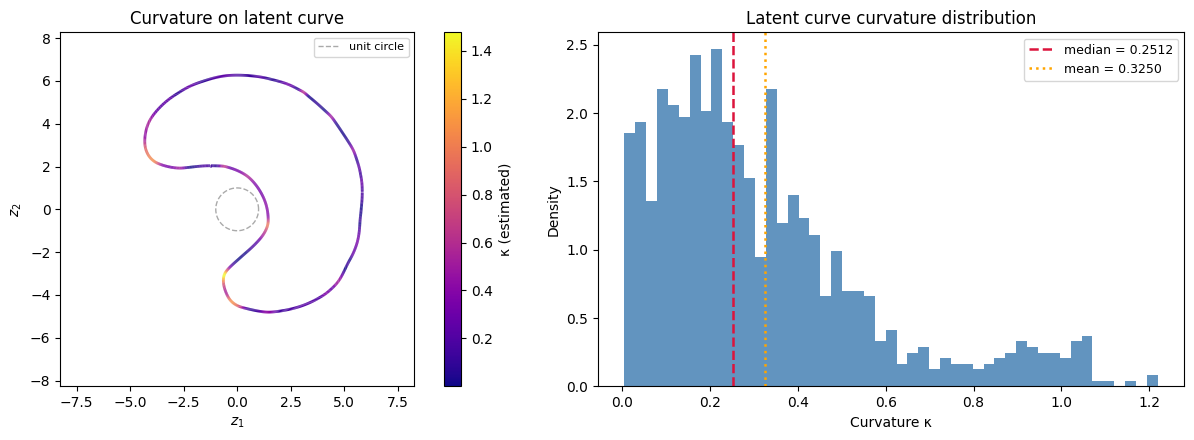

In [8]:

# ── Curvature of the latent curve ─────────────────────────────────────────────
# zs_final : (1000, 2)  —  1D curve embedded in R²
# Method   : for each point, fit a degree-2 polynomial in local tangent coords,
#            then κ = 2|β₂|  (same estimator as 02-lfs-estimation.ipynb)

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# Adaptive bandwidth: median distance to the k-th nearest neighbour
K_NBR = 20
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=K_NBR + 1).fit(zs_final)
dists, _ = nn.kneighbors(zs_final)
h_adapt = float(np.median(dists[:, -1]))   # median dist to K_NBR-th NN
print(f'Adaptive bandwidth h = {h_adapt:.4f}  (median {K_NBR}-NN distance)')

kappas = []
for i, p in enumerate(zs_final):
    diff      = zs_final - p
    dist      = np.linalg.norm(diff, axis=1)
    neighbors = diff[dist < h_adapt]

    if len(neighbors) < 6:
        kappas.append(np.nan)
        continue

    pca = PCA(n_components=2).fit(neighbors)
    tangent, normal = pca.components_[0], pca.components_[1]

    y = neighbors @ tangent   # tangential coordinate
    z = neighbors @ normal    # normal coordinate

    Y_poly = np.column_stack([y**2, y, np.ones_like(y)])
    reg    = LinearRegression().fit(Y_poly, z)
    kappas.append(2 * abs(reg.coef_[0]))

kappas = np.array(kappas)
valid  = np.isfinite(kappas)
print(f'Estimated {valid.sum()} / {len(kappas)} points successfully')
print(f'κ  mean={kappas[valid].mean():.4f}  median={np.median(kappas[valid]):.4f}  '
      f'min={kappas[valid].min():.4f}  max={kappas[valid].max():.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: curvature coloured on the latent curve itself
ax = axes[0]
pts      = np.vstack([zs_final, zs_final[:1]])
kap_c    = np.append(kappas, kappas[0])
from matplotlib.collections import LineCollection
segs     = [pts[i:i+2] for i in range(len(pts)-1)]
lc_kap   = LineCollection(segs, array=kap_c[:-1],
                           cmap='plasma', linewidth=2, zorder=2)
ax.add_collection(lc_kap)
plt.colorbar(lc_kap, ax=ax, label='κ (estimated)')
t_circ = np.linspace(0, 2*math.pi, 300)
ax.plot(np.cos(t_circ), np.sin(t_circ), '--', color='#aaaaaa',
        linewidth=1, label='unit circle')
zlim = max(float(np.abs(zs_final).max()), 1.1) + 2
ax.set_xlim(-zlim, zlim); ax.set_ylim(-zlim, zlim)
ax.set_aspect('equal')
ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
ax.set_title('Curvature on latent curve')
ax.legend(fontsize=8)

# Right: histogram
ax = axes[1]
q_lo, q_hi = np.percentile(kappas[valid], [1, 99])
bins = np.linspace(q_lo, q_hi, 50)
ax.hist(kappas[valid], bins=bins, color='steelblue', edgecolor='none',
        alpha=0.85, density=True)
ax.axvline(np.median(kappas[valid]), color='crimson', lw=1.8, ls='--',
           label=f'median = {np.median(kappas[valid]):.4f}')
ax.axvline(np.mean(kappas[valid]),   color='orange',  lw=1.8, ls=':',
           label=f'mean = {kappas[valid].mean():.4f}')
ax.set_xlabel('Curvature κ')
ax.set_ylabel('Density')
ax.set_title('Latent curve curvature distribution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'latent_curvature.png'), dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig)
